**AVANCE TRABAJO PARCIAL 19/05**

In [12]:

# TRABAJO PARCIAL 1 - INGENIERÍA DE PROCESOS
# Dataset: dirty_ecommerce_logistics_route_planning_dataset.csv

# 1. IMPORTAR LIBRERÍAS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats




In [3]:
# 2. CARGAR DATASET

datos = pd.read_csv("dirty_ecommerce_logistics_route_planning_dataset.csv")


print(datos.head())

   order_latitude  order_longitude  distance_km  delivery_time_window_hrs  \
0       12.949816        77.474053    13.823579                 16.472169   
1       13.180286        77.616760    13.101961                 19.323672   
2       13.092798        77.749178    45.406474                  6.760762   
3       13.039463        77.692890    13.227764                 15.372104   
4       12.862407        77.722624    14.325537                 14.150158   

   order_priority  vehicle_capacity_kg  order_weight_kg  \
0               2                  500        42.944053   
1               1                  127        37.747730   
2               4                  636        40.450726   
3               1                  157         7.705413   
4               3                  597         4.416252   

   vehicle_utilization_ratio  traffic_density_index  average_speed_kmph  \
0                   0.538677               0.910270           27.918127   
1                   0.863826    

In [4]:
# 3. VARIABLES NUMÉRICAS

varnum = [
    "distance_km",
    "delivery_time_window_hrs",
    "order_priority",
    "vehicle_capacity_kg",
    "order_weight_kg",
    "vehicle_utilization_ratio",
    "traffic_density_index",
    "average_speed_kmph",
    "weather_impact_index",
    "time_of_day",
    "fuel_cost_per_km",
    "driver_cost_per_hour",
    "optimized_route_time_min",
    "optimized_route_cost",
    "delivery_efficiency_score",
    "route_reliability_index"
]

In [5]:
# 4. ESTADÍSTICA DESCRIPTIVA

resumen = pd.DataFrame({
    "Media": datos[varnum].mean(),
    "Mediana": datos[varnum].median(),
    "Moda": datos[varnum].mode().iloc[0],
    "Desv.Std": datos[varnum].std(),
    "Varianza": datos[varnum].var(),
    "CV(%)": ((datos[varnum].std() / datos[varnum].mean()) * 100),
    "Asimetría": datos[varnum].skew(),
    "Curtosis": datos[varnum].kurtosis()
}).round(2)

print(resumen)




                             Media  Mediana       Moda  Desv.Std  \
distance_km                 127.17    25.77    9999.00   1002.43   
delivery_time_window_hrs     12.33    12.21       1.02      6.60   
order_priority                3.08     3.00       3.00      7.43   
vehicle_capacity_kg         541.37   548.00     178.00    263.02   
order_weight_kg              24.69    23.97       1.58     14.44   
vehicle_utilization_ratio     0.65     0.65       0.34      0.20   
traffic_density_index         0.61     0.62       0.26      0.23   
average_speed_kmph           38.81    34.86     -25.00     60.05   
weather_impact_index          0.50     0.51       0.01      0.29   
time_of_day                  11.94    12.00      19.00      7.10   
fuel_cost_per_km             10.11    10.09       5.59      2.88   
driver_cost_per_hour        248.77   246.41     100.05     88.30   
optimized_route_time_min     73.84    56.35       8.15     65.66   
optimized_route_cost       1531.79   489.56  125

In [6]:
# 5. IDENTIFICACIÓN DE OUTLIERS CON MÉTODO IQR

outliers_info = []

for var in varnum:
    df = datos[var].dropna()

    Q1 = df.quantile(0.25)
    Q3 = df.quantile(0.75)
    IQR = Q3 - Q1

    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR

    outliers = df[(df < lim_inf) | (df > lim_sup)]

    porcentaje = (len(outliers) / len(datos)) * 100

    if len(outliers) > 0:
        outliers_info.append({
            "Variable": var,
            "N° outliers": len(outliers),
            "% del total": round(porcentaje, 2),
            "Rango válido aproximado": f"{round(lim_inf, 2)} a {round(lim_sup, 2)}"
        })

outliers_df = pd.DataFrame(outliers_info)

print(outliers_df)




                    Variable  N° outliers  % del total Rango válido aproximado
0                distance_km           10         0.97           -23.47 a 75.7
1             order_priority            6         0.58              -1.0 a 7.0
2         average_speed_kmph           10         0.97          -16.94 a 87.02
3   optimized_route_time_min           63         6.12         -77.72 a 204.55
4       optimized_route_cost           32         3.11       -541.89 a 1574.04
5  delivery_efficiency_score          118        11.46            -0.08 a 0.18


/tmp/ipykernel_2185/96540678.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([rend], labels=["Costo optimizado de ruta"])


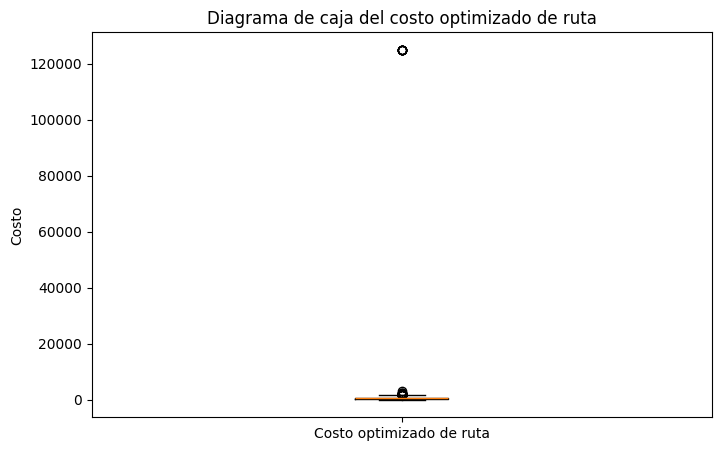

In [7]:
# 6. DIAGRAMA DE CAJA DE LA VARIABLE OBJETIVO

rend = datos["optimized_route_cost"].dropna()

plt.figure(figsize=(8, 5))
plt.boxplot([rend], labels=["Costo optimizado de ruta"])
plt.title("Diagrama de caja del costo optimizado de ruta")
plt.ylabel("Costo")
plt.show()


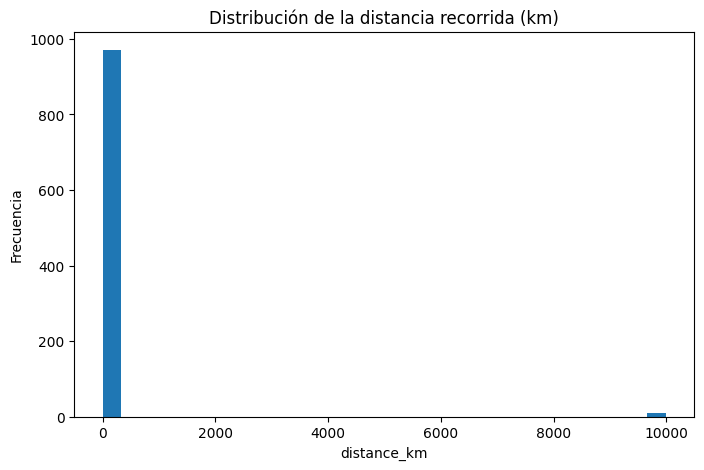

In [8]:
# 7. HISTOGRAMA DE DISTANCE_KM

plt.figure(figsize=(8, 5))
plt.hist(datos["distance_km"].dropna(), bins=30)
plt.title("Distribución de la distancia recorrida (km)")
plt.xlabel("distance_km")
plt.ylabel("Frecuencia")
plt.show()


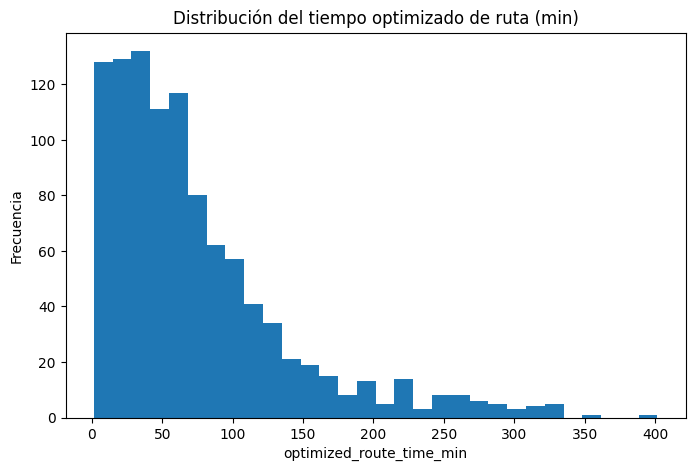

In [9]:
# 8. HISTOGRAMA DE OPTIMIZED_ROUTE_TIME_MIN

plt.figure(figsize=(8, 5))
plt.hist(datos["optimized_route_time_min"].dropna(), bins=30)
plt.title("Distribución del tiempo optimizado de ruta (min)")
plt.xlabel("optimized_route_time_min")
plt.ylabel("Frecuencia")
plt.show()


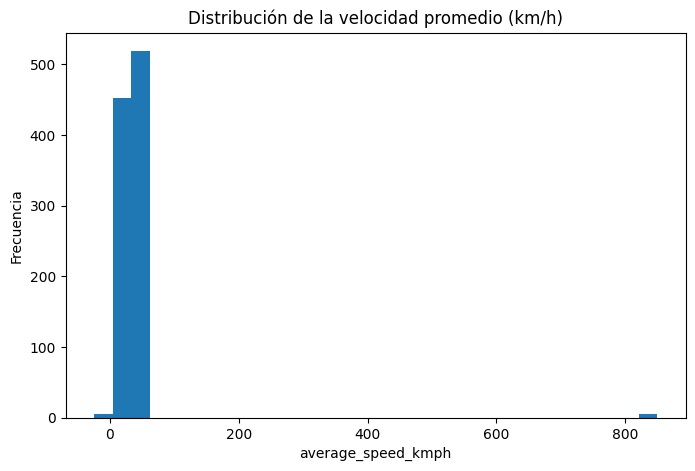

In [10]:
# 9. HISTOGRAMA DE AVERAGE_SPEED_KMPH

plt.figure(figsize=(8, 5))
plt.hist(datos["average_speed_kmph"].dropna(), bins=30)
plt.title("Distribución de la velocidad promedio (km/h)")
plt.xlabel("average_speed_kmph")
plt.ylabel("Frecuencia")
plt.show()

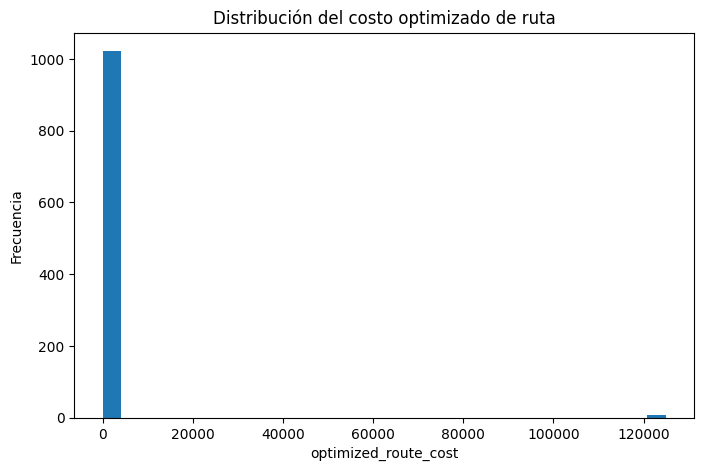

In [11]:
# 10. HISTOGRAMA DE OPTIMIZED_ROUTE_COST

plt.figure(figsize=(8, 5))
plt.hist(datos["optimized_route_cost"].dropna(), bins=30)
plt.title("Distribución del costo optimizado de ruta")
plt.xlabel("optimized_route_cost")
plt.ylabel("Frecuencia")
plt.show()

In [13]:
# 11. REVISIÓN GENERAL DEL DATASET

print(datos)

print("\nInformación general del dataset:")
datos.info()

print("\nEstadísticas descriptivas generales:")
print(datos.describe(include="all").round(2))

print("\nValores nulos por columna:")
nulos = datos.isnull().sum()
print(nulos)

print("\nDatos duplicados:")
duplicados = datos.duplicated().sum()
print(duplicados)

      order_latitude  order_longitude  distance_km  delivery_time_window_hrs  \
0          12.949816        77.474053    13.823579                 16.472169   
1          13.180286        77.616760    13.101961                 19.323672   
2          13.092798        77.749178    45.406474                  6.760762   
3          13.039463        77.692890    13.227764                 15.372104   
4          12.862407        77.722624    14.325537                 14.150158   
...              ...              ...          ...                       ...   
1025       13.088981        77.547411    30.067857                  6.386678   
1026       13.054564        77.787641    27.118414                 18.212840   
1027       13.075361        77.691176     3.531767                  3.193301   
1028       12.872574        77.704396     1.000570                 22.046397   
1029       13.160007        77.458981    25.935637                 14.856337   

      order_priority  vehicle_capacity_

In [14]:
# 12. TABLA DE VALORES NULOS Y PORCENTAJE

nulos_tabla = pd.DataFrame({
    "N° nulos": datos.isnull().sum(),
    "% del total": (datos.isnull().sum() / len(datos)) * 100
}).round(2)

print(nulos_tabla)

                           N° nulos  % del total
order_latitude                    0         0.00
order_longitude                   0         0.00
distance_km                      49         4.76
delivery_time_window_hrs          0         0.00
order_priority                    0         0.00
vehicle_capacity_kg               0         0.00
order_weight_kg                  50         4.85
vehicle_utilization_ratio        50         4.85
traffic_density_index             0         0.00
average_speed_kmph               49         4.76
weather_impact_index              0         0.00
time_of_day                       0         0.00
fuel_cost_per_km                 50         4.85
driver_cost_per_hour             50         4.85
optimized_route_time_min          0         0.00
optimized_route_cost              0         0.00
delivery_efficiency_score         0         0.00
route_reliability_index           0         0.00


In [15]:
# 13. LIMPIEZA DE DATOS

datos_limpios = datos.copy()

# Eliminar duplicados
datos_limpios = datos_limpios.drop_duplicates()

# Reemplazar valores inconsistentes en distance_km
mediana_distance = datos_limpios["distance_km"].median()
datos_limpios.loc[
    (datos_limpios["distance_km"] <= 0) |
    (datos_limpios["distance_km"] > 1000),
    "distance_km"
] = mediana_distance

# Imputar nulos de distance_km con mediana
datos_limpios["distance_km"] = datos_limpios["distance_km"].fillna(
    datos_limpios["distance_km"].median()
)

# Reemplazar valores inconsistentes en order_priority
moda_priority = datos_limpios["order_priority"].mode()[0]
datos_limpios.loc[
    ~datos_limpios["order_priority"].isin([1, 2, 3, 4]),
    "order_priority"
] = moda_priority

# Imputar nulos de order_weight_kg con mediana
datos_limpios["order_weight_kg"] = datos_limpios["order_weight_kg"].fillna(
    datos_limpios["order_weight_kg"].median()
)

# Imputar nulos de vehicle_utilization_ratio con mediana
datos_limpios["vehicle_utilization_ratio"] = datos_limpios["vehicle_utilization_ratio"].fillna(
    datos_limpios["vehicle_utilization_ratio"].median()
)

# Reemplazar valores inconsistentes en average_speed_kmph
mediana_speed = datos_limpios["average_speed_kmph"].median()
datos_limpios.loc[
    (datos_limpios["average_speed_kmph"] <= 0) |
    (datos_limpios["average_speed_kmph"] > 150),
    "average_speed_kmph"
] = mediana_speed

# Imputar nulos de average_speed_kmph con mediana
datos_limpios["average_speed_kmph"] = datos_limpios["average_speed_kmph"].fillna(
    datos_limpios["average_speed_kmph"].median()
)

# Reemplazar valores inconsistentes en time_of_day
moda_time = datos_limpios["time_of_day"].mode()[0]
datos_limpios.loc[
    (datos_limpios["time_of_day"] < 0) |
    (datos_limpios["time_of_day"] > 23),
    "time_of_day"
] = moda_time

# Imputar nulos de fuel_cost_per_km con mediana
datos_limpios["fuel_cost_per_km"] = datos_limpios["fuel_cost_per_km"].fillna(
    datos_limpios["fuel_cost_per_km"].median()
)

# Imputar nulos de driver_cost_per_hour con mediana
datos_limpios["driver_cost_per_hour"] = datos_limpios["driver_cost_per_hour"].fillna(
    datos_limpios["driver_cost_per_hour"].median()
)

# Reemplazar valores extremos de optimized_route_cost con mediana
mediana_cost = datos_limpios["optimized_route_cost"].median()
datos_limpios.loc[
    datos_limpios["optimized_route_cost"] > 10000,
    "optimized_route_cost"
] = mediana_cost

# Reemplazar valores fuera de rango en delivery_efficiency_score
mediana_efficiency = datos_limpios["delivery_efficiency_score"].median()
datos_limpios.loc[
    (datos_limpios["delivery_efficiency_score"] < 0) |
    (datos_limpios["delivery_efficiency_score"] > 1),
    "delivery_efficiency_score"
] = mediana_efficiency

print("\nDataset limpio:")
print(datos_limpios.head())

print("\nValores nulos después de la limpieza:")
print(datos_limpios.isnull().sum())

print("\nDuplicados después de la limpieza:")
print(datos_limpios.duplicated().sum())


Dataset limpio:
   order_latitude  order_longitude  distance_km  delivery_time_window_hrs  \
0       12.949816        77.474053    13.823579                 16.472169   
1       13.180286        77.616760    13.101961                 19.323672   
2       13.092798        77.749178    45.406474                  6.760762   
3       13.039463        77.692890    13.227764                 15.372104   
4       12.862407        77.722624    14.325537                 14.150158   

   order_priority  vehicle_capacity_kg  order_weight_kg  \
0               2                  500        42.944053   
1               1                  127        37.747730   
2               4                  636        40.450726   
3               1                  157         7.705413   
4               3                  597         4.416252   

   vehicle_utilization_ratio  traffic_density_index  average_speed_kmph  \
0                   0.538677               0.910270           27.918127   
1              

In [16]:
# 14. MATRIZ DE CORRELACIÓN DE SPEARMAN

num_vars = [
    "distance_km",
    "delivery_time_window_hrs",
    "order_priority",
    "vehicle_capacity_kg",
    "order_weight_kg",
    "vehicle_utilization_ratio",
    "traffic_density_index",
    "average_speed_kmph",
    "weather_impact_index",
    "time_of_day",
    "fuel_cost_per_km",
    "driver_cost_per_hour",
    "optimized_route_time_min",
    "optimized_route_cost",
    "delivery_efficiency_score",
    "route_reliability_index"
]

corr = datos_limpios[num_vars].corr(method="spearman")

print(corr)

                           distance_km  delivery_time_window_hrs  \
distance_km                   1.000000                 -0.022909   
delivery_time_window_hrs     -0.022909                  1.000000   
order_priority                0.012630                  0.023317   
vehicle_capacity_kg           0.016435                  0.017686   
order_weight_kg               0.025286                 -0.057136   
vehicle_utilization_ratio    -0.064786                  0.051772   
traffic_density_index        -0.038018                  0.048240   
average_speed_kmph           -0.034617                  0.002993   
weather_impact_index         -0.020325                 -0.021213   
time_of_day                   0.061279                 -0.021339   
fuel_cost_per_km              0.000762                  0.057275   
driver_cost_per_hour          0.028255                  0.013815   
optimized_route_time_min      0.775322                 -0.017553   
optimized_route_cost          0.835784          

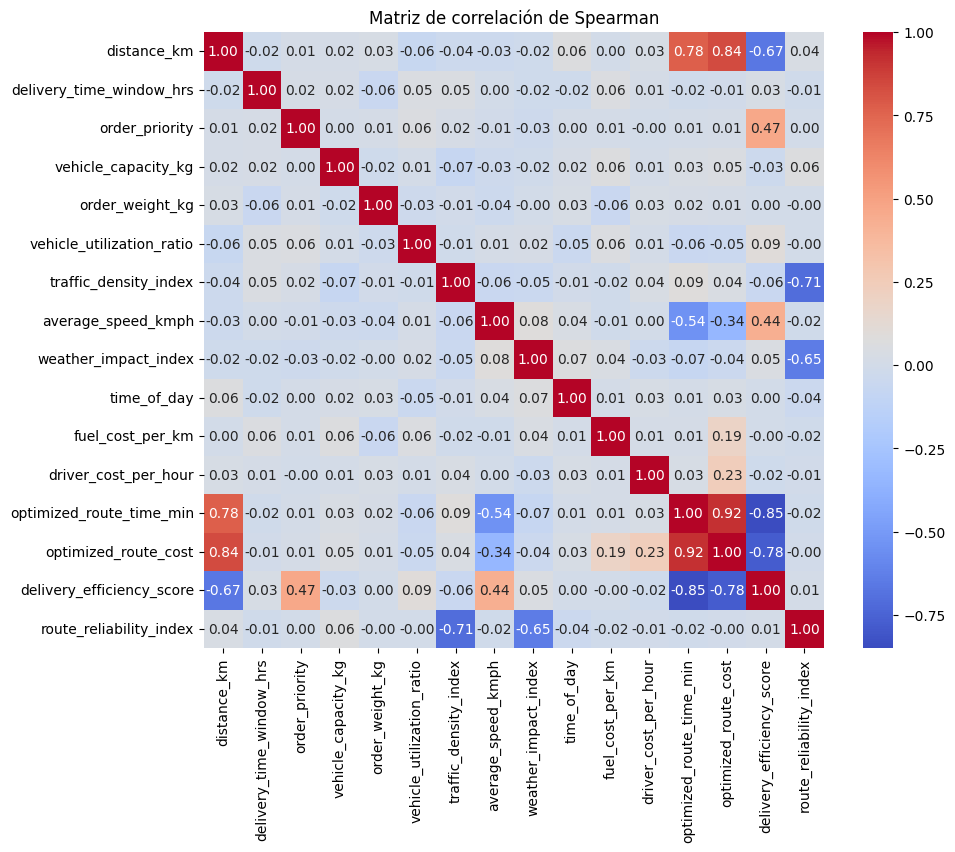

In [17]:
# 15. HEATMAP DE CORRELACIÓN

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación de Spearman")
plt.show()

In [18]:
# 16. SELECCIONAR VARIABLES PARA LA PRUEBA ESTADÍSTICA

variables = datos_limpios[["distance_km", "optimized_route_cost"]]

print("Cantidad de registros por variable:")
print(variables.count())

print("\nTipo de datos:")
print(variables.dtypes)

Cantidad de registros por variable:
distance_km             1016
optimized_route_cost    1016
dtype: int64

Tipo de datos:
distance_km             float64
optimized_route_cost    float64
dtype: object


In [19]:
# 17. PRUEBA DE NORMALIDAD KOLMOGOROV-SMIRNOV

distancia = datos_limpios["distance_km"].dropna()
costo = datos_limpios["optimized_route_cost"].dropna()

ks_distancia = stats.kstest(
    distancia,
    "norm",
    args=(distancia.mean(), distancia.std())
)

ks_costo = stats.kstest(
    costo,
    "norm",
    args=(costo.mean(), costo.std())
)

print(f"K-S Distance_km: D={ks_distancia.statistic:.4f}, p={ks_distancia.pvalue:.6f}")
print(f"K-S Optimized_route_cost: D={ks_costo.statistic:.4f}, p={ks_costo.pvalue:.6f}")

K-S Distance_km: D=0.0555, p=0.003651
K-S Optimized_route_cost: D=0.0909, p=0.000000


In [20]:
# 18. PRUEBA DE CORRELACIÓN DE SPEARMAN

df_corr = datos_limpios[["distance_km", "optimized_route_cost"]].dropna()

rho, p_valor = stats.spearmanr(
    df_corr["distance_km"],
    df_corr["optimized_route_cost"]
)

print(f"Spearman rho: {rho:.4f}, p={p_valor:.6f}")

Spearman rho: 0.8358, p=0.000000


In [21]:
# 19. CÁLCULO E INTERPRETACIÓN ESTADÍSTICA

print("Spearman (ρ):", round(rho, 4))
print("p-valor:", round(p_valor, 6))

print("Media Distance_km:", round(df_corr["distance_km"].mean(), 2))
print("Media Optimized_route_cost:", round(df_corr["optimized_route_cost"].mean(), 2))

Spearman (ρ): 0.8358
p-valor: 0.0
Media Distance_km: 25.63
Media Optimized_route_cost: 566.16


In [22]:
# 20. INTERPRETACIÓN DE LA FUERZA DE CORRELACIÓN

if abs(rho) >= 0.80:
    print("Tamaño del efecto: Muy fuerte")
elif abs(rho) >= 0.60:
    print("Tamaño del efecto: Fuerte")
elif abs(rho) >= 0.40:
    print("Tamaño del efecto: Moderado")
elif abs(rho) >= 0.20:
    print("Tamaño del efecto: Débil")
else:
    print("Tamaño del efecto: Muy débil")

print(f"Coeficiente Spearman (ρ): {rho:.4f}")

Tamaño del efecto: Muy fuerte
Coeficiente Spearman (ρ): 0.8358


In [23]:
# 21. DECISIÓN ESTADÍSTICA

alpha = 0.05

if p_valor < alpha:
    print("Decisión estadística: Se rechaza H0")
    print("Existe una relación significativa entre distance_km y optimized_route_cost.")
else:
    print("Decisión estadística: No se rechaza H0")
    print("No existe evidencia suficiente de relación significativa entre las variables.")

Decisión estadística: Se rechaza H0
Existe una relación significativa entre distance_km y optimized_route_cost.


In [24]:

# 22. GUARDAR DATASET LIMPIO

datos_limpios.to_csv("dataset_limpio_ecommerce_logistics.csv", index=False)

print("Dataset limpio guardado correctamente.")

Dataset limpio guardado correctamente.


**AVANCE DE TRABAJO FINAL 11/07**

In [29]:
# 24. FEATURE ENGINEERING

datos_fe = datos_limpios.copy()

# Costo total estimado de combustible en la ruta
datos_fe["fuel_cost_total"] = datos_fe["distance_km"] * datos_fe["fuel_cost_per_km"]

# Costo total estimado del conductor
datos_fe["driver_cost_total"] = datos_fe["delivery_time_window_hrs"] * datos_fe["driver_cost_per_hour"]

# Indicador de hora punta (7-9am y 6-8pm)
datos_fe["is_peak_hour"] = datos_fe["time_of_day"].apply(
    lambda h: 1 if (7 <= h <= 9) or (18 <= h <= 20) else 0
)

# Indice combinado de condiciones adversas (trafico + clima)
datos_fe["adverse_conditions_index"] = (datos_fe["traffic_density_index"] + datos_fe["weather_impact_index"]) / 2

# Se descartan lat/long porque no se hace analisis espacial
datos_fe = datos_fe.drop(columns=["order_latitude", "order_longitude"])

print(datos_fe.head())

   distance_km  delivery_time_window_hrs  order_priority  vehicle_capacity_kg  \
0    13.823579                 16.472169               2                  500   
1    13.101961                 19.323672               1                  127   
2    45.406474                  6.760762               4                  636   
3    13.227764                 15.372104               1                  157   
4    14.325537                 14.150158               3                  597   

   order_weight_kg  vehicle_utilization_ratio  traffic_density_index  \
0        42.944053                   0.538677               0.910270   
1        37.747730                   0.863826               0.564099   
2        40.450726                   0.537028               0.644730   
3         7.705413                   0.338803               0.523181   
4         4.416252                   0.687931               0.568094   

   average_speed_kmph  weather_impact_index  time_of_day  fuel_cost_per_km  \
0 

In [30]:
# 25. VARIABLES X e y

# Variable objetivo: optimized_route_time_min
# Se excluyen optimized_route_cost, delivery_efficiency_score y route_reliability_index
# porque son resultado de la ruta (leakage), no causas

X = datos_fe.drop(columns=["optimized_route_time_min", "optimized_route_cost",
                            "delivery_efficiency_score", "route_reliability_index"])
y = datos_fe["optimized_route_time_min"]

print(X.columns.tolist())


['distance_km', 'delivery_time_window_hrs', 'order_priority', 'vehicle_capacity_kg', 'order_weight_kg', 'vehicle_utilization_ratio', 'traffic_density_index', 'average_speed_kmph', 'weather_impact_index', 'time_of_day', 'fuel_cost_per_km', 'driver_cost_per_hour', 'fuel_cost_total', 'driver_cost_total', 'is_peak_hour', 'adverse_conditions_index']


In [31]:
# 26. TRAIN / TEST SPLIT

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train:", X_train.shape[0])
print("Test:", X_test.shape[0])


Train: 812
Test: 204


In [32]:
# 27. ESCALADO (necesario para KNN y Red Neuronal)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

In [33]:
# ## Modelo 1: Árbol de Decisión

# 28. ARBOL DE DECISION + GRIDSEARCHCV

from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
import numpy as np

param_tree = {"max_depth": [3, 5, 7]}

grid_tree = GridSearchCV(DecisionTreeRegressor(random_state=42), param_tree, cv=5)
grid_tree.fit(X_train, y_train)

modelo_tree = grid_tree.best_estimator_
pred_tree = modelo_tree.predict(X_test)

print("Mejor max_depth:", grid_tree.best_params_)
print("MAE:", mean_absolute_error(y_test, pred_tree))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_tree)))
print("R2:", r2_score(y_test, pred_tree))

Mejor max_depth: {'max_depth': 5}
MAE: 15.063643841147623
RMSE: 24.303896239443525
R2: 0.8787672213586994


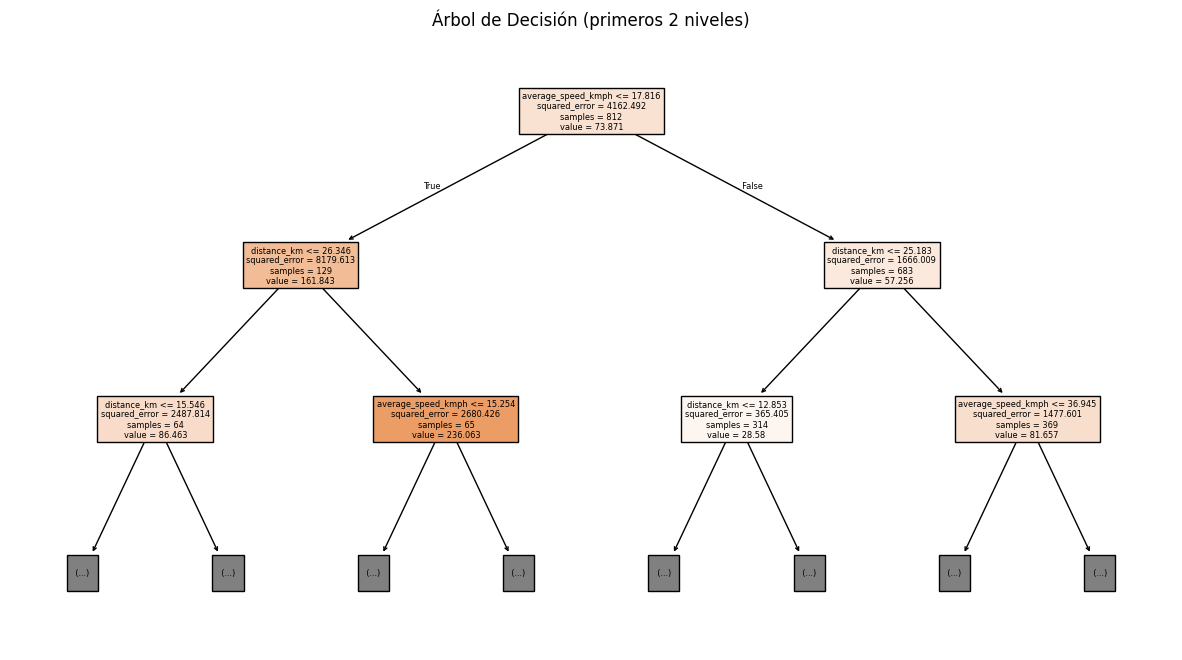

In [34]:
# 29. GRAFICO DEL ARBOL DE DECISION

plt.figure(figsize=(15, 8))
plot_tree(modelo_tree, feature_names=X.columns, filled=True, max_depth=2)
plt.title("Árbol de Decisión (primeros 2 niveles)")
plt.show()

In [35]:
# 30. IMPORTANCIA DE VARIABLES (ARBOL DE DECISION)

importancias = pd.DataFrame({
    "variable": X.columns,
    "importancia": modelo_tree.feature_importances_
}).sort_values("importancia", ascending=False)

print(importancias)


                     variable  importancia
7          average_speed_kmph     0.503465
0                 distance_km     0.487820
1    delivery_time_window_hrs     0.006392
9                 time_of_day     0.001027
8        weather_impact_index     0.000765
12            fuel_cost_total     0.000531
3         vehicle_capacity_kg     0.000000
2              order_priority     0.000000
6       traffic_density_index     0.000000
5   vehicle_utilization_ratio     0.000000
4             order_weight_kg     0.000000
10           fuel_cost_per_km     0.000000
11       driver_cost_per_hour     0.000000
13          driver_cost_total     0.000000
14               is_peak_hour     0.000000
15   adverse_conditions_index     0.000000


In [36]:
# ## Modelo 2: KNN

# 31. KNN

from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_sc, y_train)
pred_knn = knn.predict(X_test_sc)

print("MAE:", mean_absolute_error(y_test, pred_knn))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_knn)))
print("R2:", r2_score(y_test, pred_knn))

MAE: 29.099999999999998
RMSE: 47.21021531323034
R2: 0.542553597256169


Mejor k (GridSearchCV): {'n_neighbors': 7}
MAE: 28.279047619047624
RMSE: 47.284402669530735
R2: 0.541114781373661


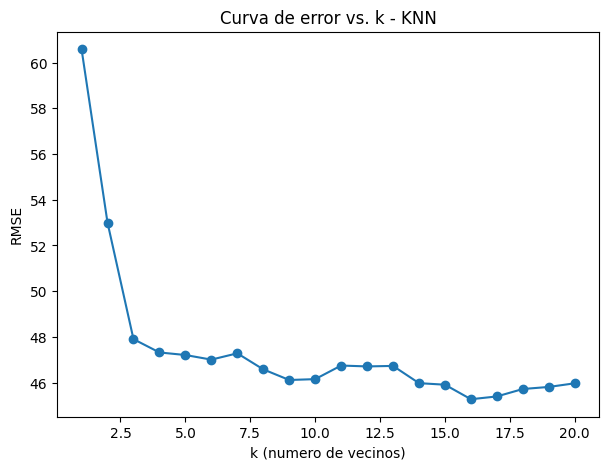

Mejor k encontrado: 16


In [53]:
# 32. CURVA DE ERROR SEGUN EL VALOR DE K

from sklearn.model_selection import GridSearchCV

param_knn = {"n_neighbors": list(range(1, 21))}

grid_knn = GridSearchCV(KNeighborsRegressor(), param_knn, cv=5)
grid_knn.fit(X_train_sc, y_train)

knn = grid_knn.best_estimator_
pred_knn = knn.predict(X_test_sc)

print("Mejor k (GridSearchCV):", grid_knn.best_params_)
print("MAE:", mean_absolute_error(y_test, pred_knn))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_knn)))
print("R2:", r2_score(y_test, pred_knn))

plt.figure(figsize=(7, 5))
plt.plot(range(1, 21), errores, marker="o")
plt.xlabel("k (numero de vecinos)")
plt.ylabel("RMSE")
plt.title("Curva de error vs. k - KNN")
plt.show()

mejor_k = list(range(1, 21))[np.argmin(errores)]
print("Mejor k encontrado:", mejor_k)

In [54]:
# ## Modelo 3: Red Neuronal (RNA)

# 33. RED NEURONAL

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

modelo_rna = Sequential()
modelo_rna.add(Dense(16, activation="relu", input_shape=(X_train_sc.shape[1],)))
modelo_rna.add(Dense(8, activation="relu"))
modelo_rna.add(Dense(1, activation="linear"))

modelo_rna.compile(optimizer="adam", loss="mse", metrics=["mae"])

early_stop = EarlyStopping(patience=10, restore_best_weights=True)

history = modelo_rna.fit(X_train_sc, y_train, epochs=100, validation_split=0.2,
                          callbacks=[early_stop], verbose=0)

pred_rna = modelo_rna.predict(X_test_sc).flatten()

print("MAE:", mean_absolute_error(y_test, pred_rna))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_rna)))
print("R2:", r2_score(y_test, pred_rna))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
MAE: 18.897591609019862
RMSE: 27.568015227300936
R2: 0.8440162868281834


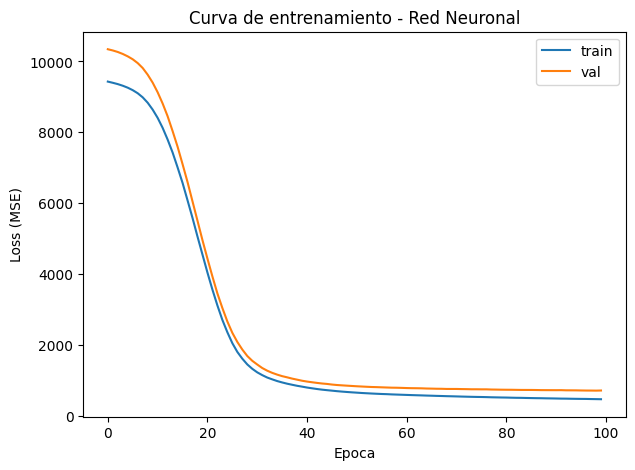

In [56]:
# 34. CURVA DE ENTRENAMIENTO (LOSS) DE LA RED NEURONAL

plt.figure(figsize=(7, 5))
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.xlabel("Epoca")
plt.ylabel("Loss (MSE)")
plt.title("Curva de entrenamiento - Red Neuronal")
plt.legend()
plt.show()


In [57]:
# ## Validación cruzada y comparación de los 3 modelos

# 35. VALIDACION CRUZADA (5 FOLDS)

from sklearn.model_selection import cross_val_score

cv_tree = cross_val_score(modelo_tree, X_train, y_train, cv=5)
cv_knn = cross_val_score(knn, X_train_sc, y_train, cv=5)

print("CV Arbol (R2 promedio):", cv_tree.mean())
print("CV KNN (R2 promedio):", cv_knn.mean())

CV Arbol (R2 promedio): 0.8559968530756954
CV KNN (R2 promedio): 0.6156776557416999


In [58]:
# 36. TABLA COMPARATIVA DE LOS 3 MODELOS

resultados = pd.DataFrame({
    "Modelo": ["Árbol de Decisión", "KNN", "Red Neuronal"],
    "MAE": [mean_absolute_error(y_test, pred_tree), mean_absolute_error(y_test, pred_knn), mean_absolute_error(y_test, pred_rna)],
    "RMSE": [np.sqrt(mean_squared_error(y_test, pred_tree)), np.sqrt(mean_squared_error(y_test, pred_knn)), np.sqrt(mean_squared_error(y_test, pred_rna))],
    "R2": [r2_score(y_test, pred_tree), r2_score(y_test, pred_knn), r2_score(y_test, pred_rna)]
})

print(resultados)


              Modelo        MAE       RMSE        R2
0  Árbol de Decisión  15.063644  24.303896  0.878767
1                KNN  28.279048  47.284403  0.541115
2       Red Neuronal  18.897592  27.568015  0.844016


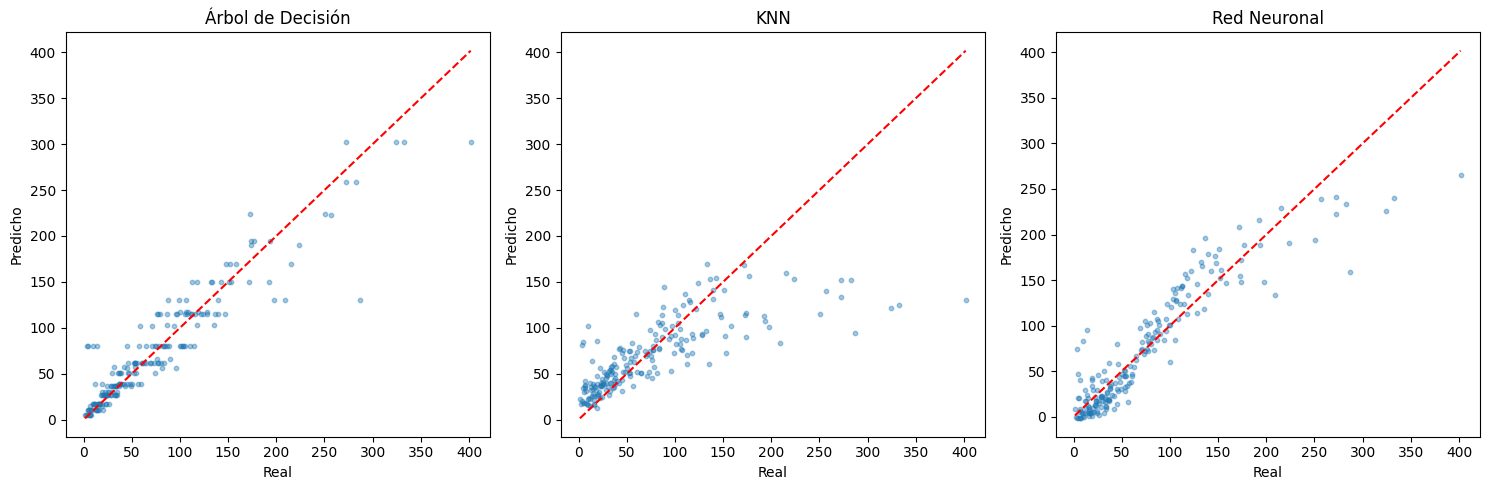

In [59]:
# 37. GRAFICO COMPARATIVO: PREDICCION VS REAL (LOS 3 MODELOS)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
preds = {"Árbol de Decisión": pred_tree, "KNN": pred_knn, "Red Neuronal": pred_rna}

for ax, (nombre, pred) in zip(axes, preds.items()):
    ax.scatter(y_test, pred, alpha=0.4, s=10)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
    ax.set_title(nombre)
    ax.set_xlabel("Real")
    ax.set_ylabel("Predicho")

plt.tight_layout()
plt.show()

In [60]:
# 38. PREDICCION CON UN CASO NUEVO

nuevo = X_test.iloc[[0]]

print("Predicción Árbol:", modelo_tree.predict(nuevo))
print("Predicción KNN:", knn.predict(scaler.transform(nuevo)))
print("Predicción RNA:", modelo_rna.predict(scaler.transform(nuevo)))


Predicción Árbol: [102.58384615]
Predicción KNN: [105.29428571]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Predicción RNA: [[83.697556]]
